# DEA Coastlines summary plots

In [ ]:
# cd ../'Tools'

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from dea_tools.coastal import get_coastlines

from scipy.stats import ttest_ind
from scipy.stats import ttest_rel

## Load data

From DEA Coastlines Knowledge Hub [Specifications](https://knowledge.dea.ga.gov.au/data/product/dea-coastlines/?tab=specifications#layers)

	
||Type|Units|Description|
|---|---|---|---|
|uid|String|-|A unique geohash identifier for each point.|
|rate_time|Float|Metres per year|Annual rates of change (in metres per year) calculated by linearly regressing annual shoreline distances against time (excluding outliers). Negative values indicate retreat and positive values indicate growth.|
|sig_time|Float|P-value|Significance (p-value) of the linear relationship between annual shoreline distances and time. Small values (e.g. p-value < 0.01 or 0.05) may indicate a coastline is undergoing consistent coastal change through time.|
|se_time|Float|Metres|Standard error (in metres) of the linear relationship between annual shoreline distances and time. This can be used to generate confidence intervals around the rate of change given by rate_time, e.g. 95% confidence interval = se_time x 1.96|
|outl_time|String|-|Individual annual shoreline are noisy estimators of coastline position that can be influenced by environmental conditions (e.g. clouds, breaking waves, sea spray) or modelling issues (e.g. poor tidal modelling results or limited clear satellite observations). To obtain reliable rates of change, outlier shorelines are excluded using a robust Median Absolute Deviation outlier detection algorithm, and recorded in this column.|
|dist_1990, dist_1991, etc|Float|Metres|Annual shoreline distances (in metres) relative to the most recent baseline shoreline. Negative values indicate that an annual shoreline was located inland of the baseline shoreline. By definition, the most recent baseline column will always have a distance of 0 m.|
|angle_mean, angle_std|Integer|Degrees|The mean angle and standard deviation between the baseline point to all annual shorelines. This data is used to calculate how well shorelines fall along a consistent line; high angular standard deviation indicates that derived rates of change are unlikely to be correct.|
|valid_obs|Integer|-|The total number of valid (i.e. non-outliers, non-missing) annual shoreline observations.|
valid_span|Integer|Years|The maximum number of years between the first and last valid annual shoreline.|
|sce|Float|Metres|Shoreline Change Envelope (SCE). A measure of the maximum change or variability across all annual shorelines, calculated by computing the maximum distance between any two annual shorelines (excluding outliers). This statistic excludes sub-annual shoreline variability.|
|nsm|Float|Metres|Net Shoreline Movement (NSM). The distance between the oldest (1988) and most recent annual shoreline (excluding outliers). Negative values indicate the coastline retreated between the oldest and most recent shoreline; positive values indicate growth. This statistic does not reflect sub-annual shoreline variability, so will underestimate the full extent of variability at any given location.|
|max_year|Integer|Date|The year that annual shorelines were at their maximum (i.e. located furthest towards the ocean), excluding outliers. This statistic excludes sub-annual shoreline variability.|
|min_year|Integer|Date|The year that annual shorelines were at their minimum (i.e. located furthest inland), excluding outliers. This statistic excludes sub-annual shoreline variability.|
|certainty|String|-|A column providing important data quality flags for each point in the dataset. For more information, see the Quality tab.|
|id_primary|String|-|The name of the point’s Primary sediment compartment from the Australian Coastal Sediment Compartments framework.|

In [2]:
# Set study area from vector file

## Use regions_gdf for mainland polygons
regions_gdf = (
    gpd.read_file(
        # "https://data.dea.ga.gov.au/derivative/dea_coastlines/supplementary/australia_mainland_regions.geojson"
        # '/home/jovyan/dev/dea-notebooks/Testing/Buffered_GBR_mngt_areas.shp' ## Management area polygons
        # '/home/jovyan/dev/dea-notebooks/Testing/Manual_all_GBR_Coastlines.shp' ## Greater GBR extent
        # '/home/jovyan/dev/dea-notebooks/Testing/Aus_bbox.shp' ## 
        # '/home/jovyan/dev/dea-notebooks/Testing/mainland_buffered_edited_mngt_regions_incl_allGBR.shp' ## all mainland only extents
        '~/gdata1/projects/coastal/SoE/Torres_Strait_2025/Torres Strait Protected Zone.shp' ## all GBR shapefiles
    )
    # .set_index("Descriptio")
    # .set_index("layer")
    # .set_index('id')
)
# regions_gdf

In [3]:
print(regions_gdf.index)
# print(regions_gdf_offshore.index)

RangeIndex(start=0, stop=1, step=1)


In [4]:
# study_area = regions_gdf.loc[['All_MackCap']]
# study_area_offshore = regions_gdf_offshore.loc[['All_GBR_offshore']]
# study_area = regions_gdf.loc[["1"]]
study_area = regions_gdf

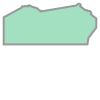

In [5]:
study_area.geometry[0]

In [20]:
# Load data from WFS for study area bounding box
bbox = study_area.geometry.bounds.values[0]
# bbox = study_area.geometry.bounds#.values[0]
ratesofchange_gdf = get_coastlines(
    bbox=bbox, layer="rates_of_change"
)

# Clip returned data to polygon extent
ratesofchange_gdf = gpd.clip(ratesofchange_gdf, mask=study_area.to_crs("EPSG:3577"))
ratesofchange_gdf

,id,uid,rate_time,sig_time,se_time,outl_time,dist_1988,dist_1989,dist_1990,dist_1991,...,angle_std,valid_obs,valid_span,sce,nsm,max_year,min_year,certainty,id_primary,geometry
8644,rates_of_change.282279,rnjk3wbu0h,-0.15,0.005,0.05,None,1.71,5.18,1.14,6.42,...,12,37,37,16.16,-1.71,1994,2023,good,QLD04,POINT (1172762.505 -1146296.120)
8645,rates_of_change.282280,rnjk3wbs1v,-0.23,0.000,0.04,None,9.73,14.22,10.57,9.38,...,5,37,37,15.41,-9.73,1994,2023,good,QLD04,POINT (1172732.586 -1146292.912)
8647,rates_of_change.282282,rnjk3wbhme,-0.17,0.000,0.03,None,8.37,9.01,5.84,5.35,...,5,37,37,12.43,-8.37,1994,2022,good,QLD04,POINT (1172674.138 -1146284.785)
8648,rates_of_change.282283,rnjk3wbkeu,-0.23,0.000,0.04,None,13.54,16.75,9.36,9.05,...,3,37,37,16.75,-13.54,1989,2024,good,QLD04,POINT (1172704.655 -1146281.910)
8649,rates_of_change.282284,rnjk3wbvhc,-0.03,0.447,0.03,None,-2.57,-1.94,-4.98,-2.21,...,9,37,37,9.57,2.57,2011,2015,good,QLD04,POINT (1172786.545 -1146280.958)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21626,rates_of_change.1009835,rnm5tqzwn7,0.61,0.028,0.23,1988 1989 1990 1991 1992 1993 1994 1995 1996 1...,NaN,NaN,NaN,NaN,...,26,10,11,10.01,NaN,2024,2015,insufficient observations,None,POINT (1163920.466 -1008120.999)
21623,rates_of_change.1009832,rnm5tqzjg2,1.55,0.040,0.63,1988 1989 1990 1991 1992 1993 1994 1995 1996 1...,NaN,NaN,NaN,NaN,...,22,10,11,27.09,NaN,2023,2015,insufficient observations,None,POINT (1163827.807 -1008119.511)
21625,rates_of_change.1009834,rnm5tqzw04,0.59,0.023,0.21,1988 1989 1990 1991 1992 1993 1994 1995 1996 1...,NaN,NaN,NaN,NaN,...,23,10,11,9.22,NaN,2022,2015,insufficient observations,None,POINT (1163889.566 -1008118.968)
21622,rates_of_change.1009831,rnm5tqyvtn,1.35,0.005,0.33,1988 1989 1990 1991 1992 1993 1994 1995 1996 1...,NaN,NaN,NaN,NaN,...,20,9,11,12.83,NaN,2023,2014,insufficient observations,None,POINT (1163796.956 -1008118.362)


In [8]:
ratesofchange_gdf.columns

Index(['id', 'uid', 'rate_time', 'sig_time', 'se_time', 'outl_time',
       'dist_1988', 'dist_1989', 'dist_1990', 'dist_1991', 'dist_1992',
       'dist_1993', 'dist_1994', 'dist_1995', 'dist_1996', 'dist_1997',
       'dist_1998', 'dist_1999', 'dist_2000', 'dist_2001', 'dist_2002',
       'dist_2003', 'dist_2004', 'dist_2005', 'dist_2006', 'dist_2007',
       'dist_2008', 'dist_2009', 'dist_2010', 'dist_2011', 'dist_2012',
       'dist_2013', 'dist_2014', 'dist_2015', 'dist_2016', 'dist_2017',
       'dist_2018', 'dist_2019', 'dist_2020', 'dist_2021', 'dist_2022',
       'dist_2023', 'dist_2024', 'angle_mean', 'angle_std', 'valid_obs',
       'valid_span', 'sce', 'nsm', 'max_year', 'min_year', 'certainty',
       'id_primary', 'geometry'],
      dtype='object')

In [ ]:
# # ## Temp - bring in csv version of Australian ratesofchange_gdf and clip to management boundaries for plotting

# from shapely import wkt

# allAus = pd.read_csv("/home/jovyan/dev/dea-notebooks/Testing/All_Aust_16-10-2023.csv")

# allAus['geometry'] = allAus['geometry'].apply(wkt.loads)
# allAus_gdf = gpd.GeoDataFrame(allAus, crs = 'epsg:3577')
# # allAus_gdf.head(2)

# ratesofchange_gdf = gpd.clip(allAus_gdf, mask=study_area.to_crs("EPSG:3577"))

# ratesofchange_gdf.head()

In [ ]:
## Temp - bring in csv version of Australian ratesofchange_gdf and clip to management boundaries for plotting
# gpd.read_file("/home/jovyan/dev/dea-notebooks/Testing/All_Aust_16-10-2023.csv")

# Reading only geometries intersecting ``mask``:

# >>> df = geopandas.read_file("nybb.shp", mask=polygon)  # doctest: +SKIP


# gdf_mask = gpd.read_file("/home/jovyan/dev/dea-notebooks/Testing/All_Aust_16-10-2023.csv", crs = 'epsg:4326')
# regions_gdf = (gpd.read_file('/home/jovyan/dev/dea-notebooks/Testing/All_GBR_merged.shp').set_index("layer"))

# allAus_gdf = allAus_gdf.to_crs(crs = 'epsg:4326')
# regions_gdf = regions_gdf.to_crs(crs = 'epsg:4326')

# gpd.read_file(allAus_gdf, mask=regions_gdf.loc[['Mainland_CairnsCook']])
# mask = regions_gdf.loc[['Australia']].geometry#.boundary
# allAus_gdf.to_crs("EPSG:3577").clip(mask)

In [ ]:
# mask_gdf = gpd.GeoDataFrame([1], geometry=mask, crs = allAus_gdf.crs)
# mask_gdf


## Data prep

In [ ]:
# ## Epoch based change
'''
This code was used for 2023 GBRMPA reporting. 

6/12/2025 CP
I'm questioning the correctness of this approach. 
I have reworked with Robbi's functions from coastlines repo below.
NOTE: there are three places in this code cell where epoch dates need to be adjusted
'''

# ## Create a linear regression object
# linear_regressor = LinearRegression()

# ## Set the dates (add 1 to your end date)

# start=1988
# end=2024

# x=np.arange(start, end+1, 1).reshape(-1,1) 
# # x=np.arange(2019, 2020, 1).reshape(-1,1) 

# ## Define the function to take each row of the gdf and calculate the linear regression 
# ## coefficient for the time period of interest
# def epoch_rate_time(x,y,linear_regressor):

#     try:
#         # If Nans in 'y', remove them and their equivalent indexed values from 'x'
#         if pd.isnull(y).any() == True:
#             x= np.delete(x, np.argwhere(y.values!=y.values).flatten(order='C')).reshape(-1,1)
#             y= y.dropna().values
#         else:
#             y = y.values
#         # Calculate the linear regression
#         linear_regressor.fit(x,y)
#         # Return only the coefficient into the gdf
#         return linear_regressor.coef_[0]
#     except:
#         # print(f'An exception error occurred at {y.id}')
#         print(f'An exception error occurred at {y}. Check that x and y the same length')

# ### rename gdf column to match input dates and adjust slices to match exact input and output years
# ratesofchange_gdf[f'{start}-{end}_epoch_rate_time'] = ratesofchange_gdf.apply(lambda y: epoch_rate_time(x,       
#                                                                                                          y.loc[f'dist_{start}':f'dist_{end}'],  
#                                                                                                          linear_regressor), 
#                                                                                                          axis=1
#                                                                                                          )
# ratesofchange_gdf.head()

In [52]:
# Long term trends. Current year baseline back to 1988

# These are edited functions from dea-coastlines GItHub repo vectors.py
from scipy.stats import linregress


def outlier_mad(points, thresh=3.5):
    """
    Use robust Median Absolute Deviation (MAD) outlier detection
    algorithm to detect outliers. Returns a boolean array with True if
    points are outliers and False otherwise.

    Parameters:
    -----------
    points :
        An n-observations by n-dimensions array of observations
    thresh :
        The modified z-score to use as a threshold. Observations with a
        modified z-score (based on the median absolute deviation) greater
        than this value will be classified as outliers.

    Returns:
    --------
    mask :
        A n-observations-length boolean array.

    References:
    ----------
    Source: https://github.com/joferkington/oost_paper_code/blob/master/utilities.py

    Boris Iglewicz and David Hoaglin (1993), "Volume 16: How to Detect and
    Handle Outliers", The ASQC Basic References in Quality Control:
    Statistical Techniques, Edward F. Mykytka, Ph.D., Editor.
    """
    if len(points.shape) == 1:
        points = points[:, None]
    median = np.median(points, axis=0)
    diff = np.sum((points - median) ** 2, axis=-1)
    diff = np.sqrt(diff)
    med_abs_deviation = np.median(diff)

    modified_z_score = 0.6745 * diff / med_abs_deviation

    return modified_z_score > thresh

def change_regress(
    y_vals,
    x_vals,
    x_labels,
    threshold=3.5,
    detrend_params=None,
    slope_var="slope",
    interc_var="intercept",
    pvalue_var="pvalue",
    stderr_var="stderr",
    outliers_var="outliers",
):
    """
    For a given row in a `pandas.DataFrame`, apply linear regression to
    data values (as y-values) and a corresponding sequence of x-values,
    and return 'slope', 'intercept', 'pvalue', and 'stderr' regression
    parameters.

    Before computing the regression, outliers are identified using a
    robust Median Absolute Deviation (MAD) outlier detection algorithm,
    and excluded from the regression. A list of these outliers will be
    recorded in the output 'outliers' variable.

    Parameters:
    -----------
    x_vals, y_vals : list of numeric values, or nd.array
        A sequence of values to use as the x and y variables
    x_labels : list
        A sequence of strings corresponding to each value in `x_vals`.
        This is used to label any observations that are flagged as
        outliers (often, this can simply be set to the same list
        provided to `x_vals`).
    threshold : float, optional
        The modified z-score to use as a threshold for detecting
        outliers using the MAD algorithm. Observations with a modified
        z-score (based on the median absolute deviation) greater
        than this value will be classified as outliers.
    detrend_params : optional
        Not currently used
    slope, interc_var, pvalue_var, stderr_var : strings, optional
        Strings giving the names to use for each of the output
        regression variables.
    outliers_var : string, optional
        String giving the name to use for the output outlier variable.

    Returns:
    --------
    mask :
        A `pandas.Series` containing regression parameters and lists
        of outliers.

    """

    # Drop invalid NaN rows
    xy_df = np.vstack([x_vals, y_vals]).T
    valid_bool = ~np.isnan(xy_df).any(axis=1)
    xy_df = xy_df[valid_bool]
    valid_labels = x_labels[valid_bool]

    # Check if we have enough data points after removing NaNs (minimum 2)
    if len(xy_df) < 2:
        # Create string of all outliers and invalid NaN rows
        outlier_set = set(x_labels) - set(valid_labels)
        outlier_str = " ".join(map(str, sorted(outlier_set)))
        
        # Return NaN values if insufficient data
        results_dict = {
            slope_var: np.nan,
            interc_var: np.nan,
            pvalue_var: np.nan,
            stderr_var: np.nan,
            outliers_var: outlier_str,
        }
        return pd.Series(results_dict)
    
    # If detrending parameters are provided, apply these to the data to
    # remove the trend prior to running the regression
    if detrend_params:
        xy_df[:, 1] = xy_df[:, 1] - (
            detrend_params[0] * xy_df[:, 0] + detrend_params[1]
        )

    # Remove outliers using MAD
    outlier_bool = outlier_mad(xy_df, thresh=threshold)
    # outlier_bool = outlier_ransac(xy_df)
    xy_df = xy_df[~outlier_bool]
    valid_labels = valid_labels[~outlier_bool]

    # Create string of all outliers and invalid NaN rows
    outlier_set = set(x_labels) - set(valid_labels)
    outlier_str = " ".join(map(str, sorted(outlier_set)))

    # Check again after outlier removal
    if len(xy_df) < 2:
        # Return NaN values if insufficient data
        results_dict = {
            slope_var: np.nan,
            interc_var: np.nan,
            pvalue_var: np.nan,
            stderr_var: np.nan,
            outliers_var: outlier_str,
        }
        return pd.Series(results_dict)
    
    # Compute linear regression
    lin_reg = linregress(x=xy_df[:, 0], y=xy_df[:, 1])

    # Return slope, p-values and list of outlier years excluded from regression
    results_dict = {
        slope_var: np.round(lin_reg.slope, 3),
        interc_var: np.round(lin_reg.intercept, 3),
        pvalue_var: np.round(lin_reg.pvalue, 3),
        stderr_var: np.round(lin_reg.stderr, 3),
        outliers_var: outlier_str,
    }

    return pd.Series(results_dict)

def calculate_regressions(points_gdf,
                         end):
    """
    For each rate of change point along the baseline annual coastline,
    compute linear regression rates of change against both time and
    climate indices.

    Regressions are computed after removing outliers to ensure robust
    results.

    Parameters:
    -----------
    points_gdf : geopandas.GeoDataFrame
        A `geopandas.GeoDataFrame` containing rates of change points
        with 'dist_*' annual movement/distance data.
    end  :  integer (optional)
        A 4 digit integer of the year you wish to set as the baseline. 
        All years after this are excluded from the rate change calculation.
        Defaults to none, setting the most recent year as the baseline.

    Returns:
    --------
    points_gdf : geopandas.GeoDataFrame
        A `geopandas.GeoDataFrame` containing rates of change points
        with additional attribute columns:

            'rate_*':  Slope of the regression
            'sig_*':   Significance of the regression
            'se_*':    Standard error of the  regression
            'outl_*':  A list of any outlier years excluded from the
                       regression
    """
    # Restrict data to years in datasets
    dist_years = points_gdf.columns[points_gdf.columns.str.contains("dist_")]
    x_years = dist_years.str.replace("dist_", "").astype(int)
    if end:
        x = x_years.where(x_years<=end).dropna().astype('int')
        dist_years = dist_years[0:len(x)]
        points_subset = points_gdf[dist_years].copy()
    else:
        points_subset = points_gdf[dist_years].copy()
    
    # Compute coastal change rates by linearly regressing annual
    # movements vs. time
    if end:
        rate_out = points_subset.apply(
            lambda row: change_regress(
                y_vals=row.values.astype(float), x_vals=x, x_labels=x
            ),
            axis=1,
            )
        points_gdf[[f"rate_time_to_{end}", f"incpt_time_to_{end}", f"sig_time_to_{end}", f"se_time_to_{end}", f"outl_time_to_{end}"]] = (
            rate_out
            )
    
    else:
        rate_out = points_subset.apply(
            lambda row: change_regress(
                y_vals=row.values.astype(float), x_vals=x_years, x_labels=x_years
            ),
            axis=1,
            )
        points_gdf[["rate_time", "incpt_time", "sig_time", "se_time", "outl_time"]] = (
                rate_out
            )
    
    # Copy slope and intercept into points_subset so they can be
    # used to temporally de-trend annual distances
    points_subset[["slope", "intercept"]] = rate_out[["slope", "intercept"]]
    
    # Custom sorting
    if end:
        reg_cols = [f"rate_time_to_{end}", f"sig_time_to_{end}", f"se_time_to_{end}", f"outl_time_to_{end}"]
    else:
        reg_cols = ["rate_time", "sig_time", "se_time", "outl_time"]
    
    
    return points_gdf.loc[
        :, [*reg_cols, *dist_years, "angle_mean", "angle_std", "geometry"]
    ]


In [22]:
# Long term trends. Current year baseline back to 1988
# Identify start/end years for long term trend analysis
# start=1988
end=2024


# # Before computing the regression, drop old columns if they exist
# old_cols = ["rate_time", "incpt_time", "sig_time", "se_time", "outl_time"]
# points_gdf = ratesofchange_gdf.drop(columns=[col for col in old_cols if col in ratesofchange_gdf.columns])


In [24]:
##Testing cell. Calculate long term change rates for a given baseline year

# Setting an 'end' date is optional. If not set, it will default to all times
start = 1988
end = 2024





Index(['id', 'uid', 'dist_1988', 'dist_1989', 'dist_1990', 'dist_1991',
       'dist_1992', 'dist_1993', 'dist_1994', 'dist_1995', 'dist_1996',
       'dist_1997', 'dist_1998', 'dist_1999', 'dist_2000', 'dist_2001',
       'dist_2002', 'dist_2003', 'dist_2004', 'dist_2005', 'dist_2006',
       'dist_2007', 'dist_2008', 'dist_2009', 'dist_2010', 'dist_2011',
       'dist_2012', 'dist_2013', 'dist_2014', 'dist_2015', 'dist_2016',
       'dist_2017', 'dist_2018', 'dist_2019', 'dist_2020', 'dist_2021',
       'dist_2022', 'dist_2023', 'dist_2024', 'angle_mean', 'angle_std',
       'valid_obs', 'valid_span', 'sce', 'nsm', 'max_year', 'min_year',
       'certainty', 'id_primary', 'geometry', 'rate_time_to_2024',
       'incpt_time_to_2024', 'sig_time_to_2024', 'se_time_to_2024',
       'outl_time_to_2024'],
      dtype='object')

In [ ]:
# For short term change use below from https://github.com/GeoscienceAustralia/dea-coastlines/blob/155ef969de9f1126d82d5ee5a7f03c942ecae118/coastlines/vector.py#L795

def annual_movements(
    points_gdf, contours_gdf, yearly_ds, baseline_year, water_index, max_valid_dist=1000
):
    """
    For each rate of change point along the baseline annual coastline,
    compute the distance to the nearest point on all neighbouring annual
    coastlines and add this data as new fields in the dataset.

    Distances are assigned a directionality (negative = located inland,
    positive = located sea-ward) by sampling water index values from the
    underlying DEA Coastlines rasters to determine if a coastline was
    located in wetter or drier terrain than the baseline coastline.

    Parameters:
    -----------
    points_gdf : geopandas.GeoDataFrame
        A `geopandas.GeoDataFrame` containing rates of change points.
    contours_gdf : geopandas.GeoDataFrame
        A `geopandas.GeoDataFrame` containing annual coastlines.
    yearly_ds : xarray.Dataset
        An `xarray.Dataset` containing annual DEA CoastLines rasters.
    baseline_year : string
        A string giving the year used as the baseline when generating
        the rates of change points dataset. This is used to load DEA
        CoastLines water index rasters to calculate change
        directionality.
    water_index : string
        A string giving the water index used in the analysis. This is
        used to load DEA CoastLines water index rasters to calculate
        change directionality.
    max_valid_dist : int or float, optional
        Any annual distance greater than this distance will be set
        to `np.nan`.

    Returns:
    --------
    points_gdf : geopandas.GeoDataFrame
        A `geopandas.GeoDataFrame` containing rates of change points
        with added 'dist_*' attribute columns giving the distance to
        each annual coastline from the baseline. Negative values
        indicate that an annual coastline was located inland of the
        baseline; positive values indicate the coastline was located
        towards the ocean.
    """

    def _point_interp(points, array, **kwargs):
        points_gs = gpd.GeoSeries(points)
        x_vals = xr.DataArray(points_gs.x, dims="z")
        y_vals = xr.DataArray(points_gs.y, dims="z")

        return array.interp(x=x_vals, y=y_vals, **kwargs)

    # Get array of water index values for baseline time period
    baseline_array = yearly_ds[water_index].sel(year=int(baseline_year))

    # Copy baseline point geometry to new column in points dataset
    points_gdf["p_baseline"] = points_gdf.geometry

    # Years to analyse
    years = contours_gdf.index.unique().values

    # Iterate through all comparison years in contour gdf
    for comp_year in years:
        # Set comparison contour
        comp_contour = contours_gdf.loc[[comp_year]].geometry.iloc[0]

        # Find nearest point on comparison contour, and add these to points dataset
        points_gdf[f"p_{comp_year}"] = points_gdf.apply(
            lambda x: nearest_points(x.p_baseline, comp_contour)[1], axis=1
        )

        # Compute distance between baseline and comparison year points and add
        # this distance as a new field named by the current year being analysed
        distances = points_gdf.apply(
            lambda x: x.geometry.distance(x[f"p_{comp_year}"]), axis=1
        )

        # Set any value over X m to NaN
        points_gdf[f"dist_{comp_year}"] = distances.where(distances < max_valid_dist)

        # Extract comparison array containing water index values for the
        # current year being analysed
        comp_array = yearly_ds[water_index].sel(year=int(comp_year))

        # Sample water index values for baseline and comparison points
        points_gdf["index_comp_p1"] = _point_interp(points_gdf.geometry, comp_array)
        points_gdf["index_baseline_p2"] = _point_interp(
            points_gdf[f"p_{comp_year}"], baseline_array
        )

        # Compute change directionality (positive = located towards the
        # ocean; negative = located inland)
        points_gdf["loss_gain"] = np.where(
            points_gdf.index_baseline_p2 > points_gdf.index_comp_p1, 1, -1
        )

        # Ensure NaNs are correctly propagated (otherwise, X > NaN
        # will return False, resulting in an incorrect land-ward direction)
        is_nan = points_gdf[["index_comp_p1", "index_baseline_p2"]].isna().any(axis=1)
        points_gdf["loss_gain"] = points_gdf["loss_gain"].where(~is_nan)

        # Multiply distance to set change to negative, positive or NaN
        points_gdf[f"dist_{comp_year}"] = (
            points_gdf[f"dist_{comp_year}"] * points_gdf.loss_gain
        )

        # Calculate compass bearing from baseline to comparison point;
        # first we need our points in lat-lon
        lat_lon = points_gdf[["p_baseline", f"p_{comp_year}"]].apply(
            lambda x: gpd.GeoSeries(x, crs=points_gdf.crs).to_crs("EPSG:4326")
        )

        geodesic = pyproj.Geod(ellps="WGS84")
        bearings = geodesic.inv(
            lons1=lat_lon.iloc[:, 0].values.x,
            lats1=lat_lon.iloc[:, 0].values.y,
            lons2=lat_lon.iloc[:, 1].values.x,
            lats2=lat_lon.iloc[:, 1].values.y,
        )[0]

        # Add bearing as a new column after first restricting
        # angles between 0 and 180 as we are only interested in
        # the overall axis of our points e.g. north-south
        points_gdf[f"bearings_{comp_year}"] = bearings % 180

    # Calculate mean and standard deviation of angles
    points_gdf["angle_mean"] = (
        points_gdf.loc[:, points_gdf.columns.str.contains("bearings_")]
        .apply(lambda x: circmean(x, high=180), axis=1)
        .round(0)
        .astype(int)
    )
    points_gdf["angle_std"] = (
        points_gdf.loc[:, points_gdf.columns.str.contains("bearings_")]
        .apply(lambda x: circstd(x, high=180), axis=1)
        .round(0)
        .astype(int)
    )

    # Keep only required columns
    to_keep = points_gdf.columns.str.contains("dist|geometry|angle")
    points_gdf = points_gdf.loc[:, to_keep]
    points_gdf = points_gdf.assign(**{f"dist_{baseline_year}": 0.0})
    points_gdf = points_gdf.round(2)

    return points_gdf

In [ ]:
# Optional: Keep only rates of change points with "good" certainty 
# (i.e. no poor quality flags)
ratesofchange_gdf = ratesofchange_gdf.query("certainty == 'good'")

# Optional: Apply correction factor from Bishop-Taylor et al. 2021
ratesofchange_gdf.rate_time += 0.08

# ratesofchange_gdf['2014-2022_epoch_rate_time']+= 0.08
# ratesofchange_gdf['2014-2017_epoch_rate_time']+= 0.08
# ratesofchange_gdf['1988-2022_epoch_rate_time']+= 0.08
# ratesofchange_gdf['2014-2018_epoch_rate_time']+= 0.08

ratesofchange_gdf[f'{start}-{end}_epoch_rate_time']+= 0.08
# ratesofchange_gdf['1988-2019_epoch_rate_time']+= 0.08

# Add x and y coords to data
ratesofchange_gdf["y_coord"] = ratesofchange_gdf.geometry.y
ratesofchange_gdf["x_coord"] = ratesofchange_gdf.geometry.x

In [ ]:
# Replace with 0 all rates with 'sig_time' > 0.01. Keep only points with statistically significant rates of change (p-value <= 0.01)

# Make a copy of the column of interest
ratesofchange_gdf[f'{start}-{end}_epoch_rate_time_sig_filtered'] = ratesofchange_gdf[f'{start}-{end}_epoch_rate_time']

## Replace with 0 all values where sig_time > 0.01
ratesofchange_gdf.loc[ratesofchange_gdf['sig_time'] > 0.01, f'{start}-{end}_epoch_rate_time_sig_filtered'] = 0
# ratesofchange_gdf[['sig_time', '2019-2022_epoch_rate_time','2019-2022_epoch_rate_time_sig_filtered']] 

## Repeat for all-time change rates
ratesofchange_gdf['rate_time_sig_filtered'] = ratesofchange_gdf['rate_time']

## Replace with 0 all values where sig_time > 0.01
ratesofchange_gdf.loc[ratesofchange_gdf['sig_time'] > 0.01, 'rate_time_sig_filtered'] = 0
ratesofchange_gdf[['sig_time', 'rate_time','rate_time_sig_filtered']] 

In [ ]:
# Resample to make sure we have evenly spaced rows (important for sensible rolling mean)
bin_size = 30
min_coord = ratesofchange_gdf["y_coord"].min()
max_coord = ratesofchange_gdf["y_coord"].max()
bin_edges = np.arange(min_coord, max_coord, bin_size)
groups = pd.cut(
    ratesofchange_gdf["y_coord"],
    bins=bin_edges,
    labels=bin_edges[:-1] + (bin_size / 2),
    right=False,
)
# ratesofchange_standardised_gdf = ratesofchange_gdf.groupby(groups).mean() ## Original code
ratesofchange_standardised_gdf = ratesofchange_gdf.groupby(groups, observed=True).mean(numeric_only=True) ## TEMPORARY CHANGE FOR TESTING 21/09/23 CP

# Set index to numeric so we can plot it nicely
ratesofchange_standardised_gdf.index = pd.to_numeric(
    ratesofchange_standardised_gdf.index
)

## Rolling mean

In [ ]:
# Apply rolling median
window_size = 1000  # km
window_n = int(window_size / 30)
ratesofchange_rolling_gdf = ratesofchange_standardised_gdf.rolling(
    window=window_n, center=True, min_periods=1
).mean()

# Apply an additional level of aesthetic smoothing (can be removed)
ratesofchange_rolling_gdf = ratesofchange_rolling_gdf.rolling(
    window=window_n, center=True, min_periods=1
).mean()

## Plotting

In [ ]:
## Set the fontsize for the plot
plt.rcParams.update({'font.size': 12})

# Common parameters for all-time and epoch plots
# Set first and last entry to zero so we get clean graph outlines
indexfirst = ratesofchange_rolling_gdf.index.min()
indexlast = ratesofchange_rolling_gdf.index.max()

In [ ]:
## All time plotting - statistically significant points only (sig_time <0.01) and good quality data (certainty = “good”)

ratesofchange_rolling_gdf.loc[indexfirst,"rate_time_sig_filtered"] = 0
ratesofchange_rolling_gdf.loc[indexlast,"rate_time_sig_filtered"] = 0

# Split out positive and negative rates so we can plot them individually
ratesofchange_positive_gdf = ratesofchange_rolling_gdf["rate_time_sig_filtered"].clip(0, np.inf)
ratesofchange_negative_gdf = ratesofchange_rolling_gdf["rate_time_sig_filtered"].clip(-np.inf, 0)

# Plot negative rates in red, positive in blue
fig, ax = plt.subplots(figsize=(2, 11.5))#7))#1.75))#5))#7))
ax.fill_betweenx(
    ratesofchange_positive_gdf.index, 0, ratesofchange_positive_gdf, color="#6caed1"
)
ax.fill_betweenx(
    ratesofchange_negative_gdf.index, ratesofchange_negative_gdf, 0, color="#eb7668"
)
ax.plot(
    ratesofchange_rolling_gdf["rate_time_sig_filtered"],
    ratesofchange_rolling_gdf.index,
    color="black",
    linewidth=1
)

# Add vertical axis line
ax.axvline(0, color="black", linewidth=1)

# Styling
ax.set_xlim(-1, 1)
ax.set_ylim(min_coord, max_coord)
ax.set_xticks(ticks=[-1, 0, 1])
ax.set_xlabel(f"(m / year between \n {start} and {end})")
ax.spines[["top", "left", "right"]].set_visible(False)
ax.tick_params(top=False, left=False, labelleft=False, labeltop=False)
# ax.text

# Export
fig.savefig(f"/home/jovyan/dev/dea-notebooks/Testing/{study_area.index[0]}_{start}_{end}_latsummary.svg", bbox_inches="tight", transparent=True)

In [ ]:
## Epoch plotting (without outlier removal - unlike original rate_time method)

# Set first and last entry to zero so we get clean graph outlines
ratesofchange_rolling_gdf.loc[indexfirst,f'{start}-{end}_epoch_rate_time_sig_filtered'] = 0
ratesofchange_rolling_gdf.loc[indexlast,f'{start}-{end}_epoch_rate_time_sig_filtered'] = 0

# Split out positive and negative rates so we can plot them individually
ratesofchange_positive_gdf = ratesofchange_rolling_gdf[f'{start}-{end}_epoch_rate_time_sig_filtered'].clip(0, np.inf)
ratesofchange_negative_gdf = ratesofchange_rolling_gdf[f'{start}-{end}_epoch_rate_time_sig_filtered'].clip(-np.inf, 0)

# Plot negative rates in red, positive in blue
fig, ax = plt.subplots(figsize=(2,11.5))#1.5, 7))#5))#7))
ax.fill_betweenx(
    ratesofchange_positive_gdf.index, 0, ratesofchange_positive_gdf, color="#6caed1"
)
ax.fill_betweenx(
    ratesofchange_negative_gdf.index, ratesofchange_negative_gdf, 0, color="#eb7668"
)
ax.plot(
    ratesofchange_rolling_gdf[f'{start}-{end}_epoch_rate_time_sig_filtered'],
    ratesofchange_rolling_gdf.index,
    color="black",
    linewidth=1,
)

# Add vertical axis line
ax.axvline(0, color="black", linewidth=1)

# Styling
ax.set_xlim(-1, 1)
ax.set_ylim(min_coord, max_coord)
ax.set_xticks(ticks=[-1, 0, 1])
ax.set_xlabel(f"(m / year between \n {start} and {end})")
ax.spines[["top", "left", "right"]].set_visible(False)
ax.tick_params(top=False, left=False, labelleft=False, labeltop=False)

# Export
fig.savefig(f"/home/jovyan/dev/dea-notebooks/Testing/{study_area.index[0]}_{start}_{end}_latsummary.svg", bbox_inches="tight", transparent=True)

In [ ]:
# ratesofchange_gdf[['sig_time', 'rate_time','rate_time_sig_filtered',f'{start}-{end}_epoch_rate_time_sig_filtered']] 

In [ ]:
# ratesofchange_rolling_gdf[['rate_time','rate_time_sig_filtered',f'{start}-{end}_epoch_rate_time_sig_filtered']].head(20)

In [ ]:
plt.plot(ratesofchange_rolling_gdf[['rate_time_sig_filtered',f'{start}-{end}_epoch_rate_time_sig_filtered']])
                # ratesofchange_rolling_gdf[f'{start}-{end}_epoch_rate_time_sig_filtered'])

In [ ]:
# ratesofchange_gdf.to_csv("/home/jovyan/dev/dea-notebooks/Testing/DEACoastlines_ratesofchange_GBR_mngt_area_all.csv")

## Tabular summaries

In [ ]:
region = 'GBR_mainland'

In [ ]:
study_area.index[0]

In [ ]:
## Baseline comparison stats for mainland polygons
v1 = ratesofchange_gdf['rate_time_sig_filtered'].values
v2 = ratesofchange_gdf['2019-2022_epoch_rate_time_sig_filtered'].values

rel = ttest_rel(v1,v2)
rel

In [ ]:
ratetimemean = ratesofchange_gdf['rate_time_sig_filtered'].mean().round(2)
ratetimestd = round(ratesofchange_gdf['rate_time_sig_filtered'].std(),2)
epochmean = ratesofchange_gdf['2019-2022_epoch_rate_time_sig_filtered'].mean().round(2)
epochstd = round(ratesofchange_gdf['2019-2022_epoch_rate_time_sig_filtered'].std(),2)

# Run once as the master dataframe
data = {
        '1988-2022':f'{ratetimemean} ({ratetimestd})', 
        '2019-2022':f'{epochmean} ({epochstd})',
        'pvalue (1988-2022 vs 2019-2022)':rel.pvalue,
        'tstat (1988-2022 vs 2019-2022)':round(rel.statistic,2),
        'df (1988-2022 vs 2019-2022)':rel.df
        }
StatSummary = pd.DataFrame(data, index=[region]) 

In [ ]:
# Append new row to dataframe
StatSummary.loc[len(StatSummary.index)] =          [f'{ratetimemean} ({ratetimestd})', 
                                                   f'{epochmean} ({epochstd})',
                                                   rel.pvalue.round(2),
                                                   round(rel.statistic,2),
                                                   rel.df]
## Update index label
StatSummary.rename(index={StatSummary.loc[len(StatSummary.index)-1].name:region},inplace=True)

In [ ]:
region = 'GBR_offshore'

In [ ]:
## Baseline comparison stats for offshore polygons
v1 = ratesofchange_gdf_offshore['rate_time_sig_filtered'].values
v2 = ratesofchange_gdf_offshore['2019-2022_epoch_rate_time_sig_filtered'].values

rel = ttest_rel(v1,v2)
rel


In [ ]:

ratetimemean = ratesofchange_gdf_offshore['rate_time_sig_filtered'].mean().round(2)
ratetimestd = round(ratesofchange_gdf_offshore['rate_time_sig_filtered'].std(),2)
epochmean = ratesofchange_gdf_offshore['2019-2022_epoch_rate_time_sig_filtered'].mean().round(2)
epochstd = round(ratesofchange_gdf_offshore['2019-2022_epoch_rate_time_sig_filtered'].std(),2)

## Run once as the master dataframe
# data = {
#         '1988-2022':f'{ratetimemean} ({ratetimestd})', 
#         '2019-2022':f'{epochmean} ({epochstd})',
#         'pvalue (1988-2022 vs 2019-2022)':rel.pvalue,
#         'tstat (1988-2022 vs 2019-2022)':round(rel.statistic,2),
#         'df (1988-2022 vs 2019-2022)':rel.df
#         }
# StatSummary = pd.DataFrame(data, index=[region]) 

# Append new row to dataframe
StatSummary.loc[len(StatSummary.index)] =          [f'{ratetimemean} ({ratetimestd})', 
                                                   f'{epochmean} ({epochstd})',
                                                   round(rel.pvalue,2),
                                                   round(rel.statistic,2),
                                                   rel.df
                                                  ]
                                          
## Update index label
StatSummary.rename(index={StatSummary.loc[len(StatSummary.index)-1].name:region},inplace=True)
StatSummary

In [ ]:
StatSummary.to_csv("/home/jovyan/dev/dea-notebooks/Testing/StatSummary.csv")

In [ ]:
region = 'GBR'

In [ ]:
v1 = ratesofchange_gdf['rate_time_sig_filtered'].values
v2 = ratesofchange_gdf_offshore['rate_time_sig_filtered'].values

rel = ttest_ind(v1,v2,equal_var=False)
rel

In [ ]:
v1 = ratesofchange_gdf['2019-2022_epoch_rate_time_sig_filtered'].values
v2 = ratesofchange_gdf_offshore['2019-2022_epoch_rate_time_sig_filtered'].values

rel2 = ttest_ind(v1,v2,equal_var=False)
rel2

In [ ]:
## Capture statistical significance in onshore vs offshore regions

## Run once as master dataframe
# data = {
#         'Onshore vs Offshore (1988-2022) tstat': rel.statistic.round(2),
#         'Onshore vs Offshore (1988-2022) pvalue': rel.pvalue.round(2),
#         'Onshore vs Offshore (2019-2022) tstat': rel2.statistic.round(2),
#         'Onshore vs Offshore (2019-2022) pvalue': rel2.pvalue.round(2)
#         }
# OnOffshoreSummary = pd.DataFrame(data, index=[region])

## Append new row to dataframe
OnOffshoreSummary.loc[len(OnOffshoreSummary.index)] = [rel.statistic.round(2),
                                                       rel.pvalue.round(2),
                                                       rel2.statistic.round(2),
                                                       rel2.pvalue.round(2)]
OnOffshoreSummary.rename(index={OnOffshoreSummary.loc[len(OnOffshoreSummary.index)-1].name:region}, inplace=True)
                                                       


In [ ]:
OnOffshoreSummary

In [ ]:
OnOffshoreSummary.to_csv("/home/jovyan/dev/dea-notebooks/Testing/OnOffshoreSummary.csv")

# After: https://gist.github.com/robbibt/760dcf367be4b98c493e70dd577aca6a

In [ ]:
def change_summary(df, sig=0.01, rate=0.30, bias=0.08):

    # Create booleans indicating whether points were significant
    # or greatert than the minimum accuracy of the method
    sig_bool = df.sig_time <= sig
    # rate_bool = (df.rate_time + bias).abs() >= rate #CP removed as the bias correction has already been applied
    rate_bool = (df.rate_time).abs() >= rate

    # Calculate dynamic % (sig points greater than min rate)
    stat_dict = {}
    stat_dict['dynamic'] = (sig_bool & rate_bool).mean()

    # Calculate stable % (non-sig points or less than min rate)
    stat_dict['stable'] = 1.0 - stat_dict['dynamic']

    # For each rate of change categoru, calculate percent greater
    # (prograding) or percent smaller (eroding coasts)

    for rate_cat in [0.0, 0.5, 1.0, 3.0, 5.0]:
        stat_dict[f'eroding_{rate_cat}'] = (
            # sig_bool & rate_bool & (df.rate_time + bias < -rate_cat)).mean() #CP removed as the bias correction has already been applied
            sig_bool & rate_bool & (df.rate_time < -rate_cat)).mean()
        stat_dict[f'prograd_{rate_cat}'] = (
            # sig_bool & rate_bool & (df.rate_time + bias > rate_cat)).mean() #CP removed as the bias correction has already been applied
            sig_bool & rate_bool & (df.rate_time > rate_cat)).mean()

    return pd.Series(stat_dict)

In [ ]:
# Load point data and Coastal Compartment regions data
# coastlines_data = gpd.read_file('../releases/DEACoastlines_v1.0.0/Shapefile/DEACoastlines_ratesofchange_v1.0.0.shp')[['rate_time', 'sig_time', 'geometry']]
coastlines_data = ratesofchange_gdf[['1988-2019_epoch_rate_time', 'sig_time', 'geometry']]
coastlines_data = coastlines_data.rename(columns={'1988-2019_epoch_rate_time' : 'rate_time'})
# acsc_regions = gpd.read_file('/g/data/r78/DEACoastlines/input_data/Coastal_compartments/Shapefiles_v3/Regions.shp').dissolve('Descriptio')
acsc_regions = regions_gdf.dissolve('layer')


In [ ]:
# Join coastal compartments to points
from geopandas import gpd 
coastlines_joined = gpd.sjoin(coastlines_data, acsc_regions.to_crs('EPSG:3577'), op='within') 

In [ ]:
regions_gdf.index

Create continental summary change table

In [ ]:
# Compute summaries of change for all regions
summary_df = coastlines_joined.groupby(['index_right']).apply(lambda x: change_summary(x)).T
summary_df['Continental'] = change_summary(df=coastlines_joined, sig=0.01)

# # Sort into pretty format
summary_df = summary_df.loc[[
    'dynamic', 'stable', 'eroding_0.0', 'eroding_0.5', 'eroding_1.0',
    'eroding_3.0', 'eroding_5.0', 'prograd_0.0', 'prograd_0.5', 'prograd_1.0',
    'prograd_3.0', 'prograd_5.0'
], [
    'Australia', 'Mainland_CairnsCook', 'Mainland_FarNorth', 'Mainland_GBR',
       'Mainland_MackCap', 'Mainland_TownsWhit', 'All_GBR',
       'Offshore_CairnsCook', 'Offshore_FarNorth', 'Offshore_GBR',
       'Offshore_MackCap', 'Offshore_TownsWhit', 'All_FarNorth',
       'All_CairnsCook', 'All_TownsWhit', 'All_MackCap'
]]

# Rename index
summary_df.index = ['Dynamic', 'Stable', 
                    'Eroding',     
                    '    > 0.5 m / year', '    > 1.0 m / year', 
                    '    > 3.0 m / year', '    > 5.0 m / year', 
                    'Prograding', 
                    '    > 0.5 m / year', '    > 1.0 m / year', 
                    '    > 3.0 m / year', '    > 5.0 m / year']

# Scale and round
(summary_df * 100).round(2)

In [ ]:
summary_df_round = (summary_df * 100).round(2)
Epoch_1988_2019_summary = summary_df_round[['Australia', 
                                      'All_GBR', 'Mainland_GBR', 'Offshore_GBR',
                                      'All_FarNorth','Mainland_FarNorth','Offshore_FarNorth', 
                                      'All_CairnsCook','Mainland_CairnsCook', 'Offshore_CairnsCook',
                                      'All_TownsWhit','Mainland_TownsWhit','Offshore_TownsWhit',
                                      'All_MackCap', 'Mainland_MackCap', 'Offshore_MackCap']]


In [ ]:
Epoch_1988_2019_summary

In [ ]:
regions_gdf.index

In [ ]:
All_time_summary.to_csv("/home/jovyan/dev/dea-notebooks/Testing/All_time_perc_summary.csv")

In [ ]:
Epoch_1988_2019_summary.to_csv("/home/jovyan/dev/dea-notebooks/Testing/Epoch_1988_2019_perc_summary.csv")

In [ ]:
ratesofchange_gdf.to_csv("/home/jovyan/dev/dea-notebooks/Testing/All_Aust_16-10-2023.csv")